# Classifying waterbody types from SAR water maps
## Jillian Greene
## March 2026

In [1]:
# Import packages
import os
import numpy as np
import rasterio
from rasterio.features import shapes
from rasterio.warp import calculate_default_transform, reproject, Resampling
import geopandas as gpd
from shapely.geometry import shape
from rasterstats import zonal_stats
from tqdm import tqdm
import folium
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from IPython.display import IFrame


In [2]:
# Read in files
nisar_water = os.path.join(os.getcwd(), "..", "data", "nisar_s1_figure", "NISAR", 'NISAR_L2_PR_GCOV_20251216_HH_water_mask.tif')

nlcd = os.path.join(os.getcwd(), "..", "data", "nisar_s1_figure", "Annual_NLCD_LndCov_2024_CU_C1V1", 'Annual_NLCD_2024_clip.tif')

nhd = os.path.join(os.getcwd(), "..", "data", "nisar_s1_figure", "NHD_H_Washington_State_Shape", 'Shape', 'NHDWaterbody.shp')

# Config settings
OUTPUT_CSV = os.path.join(os.getcwd(), "waterbody_features.csv")
OUTPUT_GPKG = os.path.join(os.getcwd(), "waterbody_features.gpkg")
TARGET_CRS = "EPSG:32610"   # WGS 84 Zone 10N (WA)
BUFFER_M = 200           # metres to buffer NLCD stats 
MIN_AREA_HA = 1.0           # drop patches smaller than this
WATER_MASK_VAL = 1             # pixel value that means "water" in NISAR mask

# NLCD classes
NLCD_CLASSES = {
    11: "open_water", 12: "perennial_ice_snow",
    21: "developed_open", 22: "developed_low", 23: "developed_med", 24: "developed_high",
    31: "barren",
    41: "deciduous_forest", 42: "evergreen_forest", 43: "mixed_forest",
    52: "shrub_scrub",
    71: "grassland_herbaceous",
    81: "pasture_hay", 82: "cultivated_crops",
    90: "woody_wetlands", 95: "emergent_herbaceous_wetlands",
}

In [12]:
# --- Create waterbody patches from pixel clusters ---

def vectorize_water_mask(tif_path: str, water_val: int = 1) -> gpd.GeoDataFrame:
    """Convert a binary water-mask GeoTIFF into a polygon GeoDataFrame."""
    print("Vectorizing NISAR water mask …")
    with rasterio.open(tif_path) as src:
        data = src.read(1)
        mask = (data == water_val).astype(np.uint8)
        crs  = src.crs
        transform = src.transform
 
        polys = [
            {"geometry": geom, "pixel_val": val}
            for geom, val in shapes(mask, mask=mask, transform=transform)
            if val == 1
        ]
 
    if not polys:
        raise ValueError("No water pixels found — check WATER_MASK_VAL.")
 
    gdf = gpd.GeoDataFrame(
        [{"geometry": shape(p["geometry"])} for p in polys],
        crs=crs
    )
    print(f"  → {len(gdf):,} raw patches")
    return gdf

def prepare_patches(gdf: gpd.GeoDataFrame,
                    target_crs: str = TARGET_CRS,
                    min_area_ha: float = MIN_AREA_HA) -> gpd.GeoDataFrame:
    """Reproject to a metric CRS and drop patches below the minimum area."""
    print(f"Reprojecting to {target_crs} …")
    gdf = gdf.to_crs(target_crs)
 
    # Area in hectares (CRS units are metres)
    gdf["area_m2"] = gdf.geometry.area
    gdf["area_ha"] = gdf["area_m2"] / 10_000
 
    before = len(gdf)
    gdf = gdf[gdf["area_ha"] >= min_area_ha].reset_index(drop=True)
    print(f"  → kept {len(gdf):,} patches ≥ {min_area_ha} ha  (dropped {before - len(gdf):,})")
    gdf["patch_id"] = gdf.index
    return gdf

In [13]:
# --- Create shape indices from patches ---

def compute_shape_indices(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Add shape metrics to each polygon:
 
      perimeter_m   – exterior ring length (metres)
      compactness   – Polsby–Popper: 4π·A / P²  (1 = perfect circle)
      circularity   – same formula, alias commonly used in remote sensing
      shape_index   – P / (2·√(π·A))  (1 = circle; higher = more irregular)
    """
    print("Computing shape indices …")
    gdf["perimeter_m"] = gdf.geometry.length
 
    A = gdf["area_m2"]
    P = gdf["perimeter_m"]
 
    gdf["compactness"]  = (4 * np.pi * A) / (P ** 2)   # Polsby–Popper [0,1]
    gdf["circularity"]  = gdf["compactness"]             # same metric, explicit alias
    gdf["shape_index"]  = P / (2 * np.sqrt(np.pi * A))  # FRAGSTATS shape index [1,∞)
 
    return gdf

In [14]:
# --- Extract riparian NLCD data ---

def reproject_raster_to_crs(src_path: str, target_crs: str) -> tuple:
    """
    Returns (data_array, transform, crs) reprojected to target_crs.
    Keeps the original resolution.
    """
    with rasterio.open(src_path) as src:
        if str(src.crs) == target_crs:
            return src.read(1), src.transform, src.crs
 
        transform, width, height = calculate_default_transform(
            src.crs, target_crs, src.width, src.height, *src.bounds
        )
        kwargs = src.meta.copy()
        kwargs.update({"crs": target_crs, "transform": transform,
                       "width": width, "height": height})
 
        data = np.empty((height, width), dtype=src.dtypes[0])
        reproject(
            source=rasterio.band(src, 1),
            destination=data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=target_crs,
            resampling=Resampling.nearest,
        )
    return data, transform, target_crs
 
 
def nlcd_buffer_context(gdf: gpd.GeoDataFrame,
                        nlcd_path: str,
                        buffer_m: float = BUFFER_M) -> gpd.GeoDataFrame:
    """
    For each patch, build a doughnut buffer (buffer ring only, excluding the
    water body itself) and compute % cover of each NLCD class within that ring.
 
    Columns added: nlcd_<class_label>_pct  for every class present.
    """
    print(f"Computing NLCD land-cover context in {buffer_m} m buffer rings …")
 
    # Reproject NLCD to TARGET_CRS in memory
    nlcd_data, nlcd_transform, nlcd_crs = reproject_raster_to_crs(nlcd_path, TARGET_CRS)
 
    # Build doughnut geometries (outer buffer minus inner patch)
    outer = gdf.geometry.buffer(buffer_m)
    rings = outer.difference(gdf.geometry)
    rings_gdf = gpd.GeoDataFrame({"patch_id": gdf["patch_id"]},
                                  geometry=rings, crs=gdf.crs)
 
    # zonal_stats returns a list of dicts with pixel value counts
    stats = zonal_stats(
        rings_gdf,
        nlcd_data,
        affine=nlcd_transform,
        categorical=True,       # count pixels per unique value
        nodata=0,
    )
 
    # Convert counts → percentages, map codes → labels
    records = []
    for row_stats in tqdm(stats, desc="  NLCD zonal stats"):
        if not row_stats:
            records.append({})
            continue
        total = sum(row_stats.values())
        if total == 0:
            records.append({})
            continue
        record = {}
        for code, count in row_stats.items():
            label = NLCD_CLASSES.get(int(code), f"nlcd_{int(code)}")
            record[f"nlcd_{label}_pct"] = round(count / total * 100, 2)
        records.append(record)
 
    nlcd_df = gpd.GeoDataFrame(records).fillna(0)
    # Ensure all known NLCD class columns exist (fill 0 if class absent in AOI)
    for code, label in NLCD_CLASSES.items():
        col = f"nlcd_{label}_pct"
        if col not in nlcd_df.columns:
            nlcd_df[col] = 0.0
 
    gdf = gdf.reset_index(drop=True)
    gdf = gdf.join(nlcd_df)
    return gdf

In [18]:
# --- Add NHD labels for training ---

def join_nhd_labels(gdf: gpd.GeoDataFrame, nhd_path: str) -> gpd.GeoDataFrame:
    """
    Spatial join to NHD waterbodies to pull in the FTYPE label
    (Lake/Pond, Reservoir, SwampMarsh, …) as a ground-truth column.
    Uses largest-overlap strategy.
    """
    print("Joining NHD labels …")
    nhd_gdf = gpd.read_file(nhd_path)[["geometry", "ftype", "fcode"]].to_crs(TARGET_CRS)
 
    joined = gpd.sjoin_nearest(
        gdf[["patch_id", "geometry"]],
        nhd_gdf,
        how="left",
        max_distance=100,       # metres – only snap if within 100 m
        distance_col="nhd_dist_m"
    )
    # Keep closest match per patch
    joined = joined.sort_values("nhd_dist_m").drop_duplicates("patch_id")
 
    gdf = gdf.merge(
        joined[["patch_id", "ftype", "fcode", "nhd_dist_m"]].rename(
            columns={"ftype": "nhd_ftype", "fcode": "nhd_fname"}
        ),
        on="patch_id", how="left"
    )
    return gdf


In [ ]:
# Run through process

# 1. Vectorize
patches = vectorize_water_mask(nisar_water, water_val=WATER_MASK_VAL)

# 2. Reproject + filter
patches = prepare_patches(patches, target_crs=TARGET_CRS, min_area_ha=MIN_AREA_HA)

# 3. Shape indices
patches = compute_shape_indices(patches)

# 4. NLCD buffer context - this step takes ~10 min
patches = nlcd_buffer_context(patches, nlcd, buffer_m=BUFFER_M)


In [19]:
# 5. (Optional) NHD label join for ground-truth
patches = join_nhd_labels(patches, nhd)

Joining NHD labels …


In [ ]:
# Export patches to HTML

# Folium needs EPSG:4326
patches_wgs84 = patches.to_crs("EPSG:4326")
 
# Colour patches by area_ha using YlOrRd
area     = patches_wgs84["area_ha"]
vmin, vmax = area.min(), area.max()
cmap_fn  = cm.get_cmap("YlOrRd")
norm     = mcolors.LogNorm(vmin=max(vmin, 0.01), vmax=vmax)  # log scale handles skew
 
def area_to_hex(val):
    rgba = cmap_fn(norm(val))
    return mcolors.to_hex(rgba)
 
# Centre map on patch centroid cloud
map_center = [
    patches_wgs84.geometry.centroid.y.mean(),
    patches_wgs84.geometry.centroid.x.mean(),
]
 
m = folium.Map(
    location=map_center,
    zoom_start=11,
    tiles="CartoDB positron",   # clean basemap 
)
 
# Optional: add a satellite layer the user can toggle - no API key required!
folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Esri World Imagery",
    name="Satellite",
    overlay=False,
    control=True,
).add_to(m)
 
# Add patches as a GeoJson layer with tooltips
def style_fn(feature):
    val = feature["properties"]["area_ha"]
    return {
        "fillColor":   area_to_hex(val),
        "color":       "steelblue",
        "weight":      0.6,
        "fillOpacity": 0.7,
    }
 
tooltip_fields = (
    ["patch_id", "area_ha", "perimeter_m", "compactness", "shape_index"]
    + [c for c in patches_wgs84.columns if c.startswith("lc_") and c.endswith("_pct")]
    + ["nhd_ftype", "nhd_fname"]
)
# Keep only columns that actually exist
tooltip_fields = [f for f in tooltip_fields if f in patches_wgs84.columns]
 
tooltip_aliases = [f.replace("_", " ").replace("lc ", "").replace(" pct", " %").title()
                   for f in tooltip_fields]
 
folium.GeoJson(
    patches_wgs84[tooltip_fields + ["geometry"]],
    name="Water patches",
    style_function=style_fn,
    tooltip=folium.GeoJsonTooltip(
        fields=tooltip_fields,
        aliases=tooltip_aliases,
        localize=True,
        sticky=True,
        labels=True,
    ),
).add_to(m)
 
# Colour bar as a custom legend
legend_html = """
<div style="
    position: fixed; bottom: 40px; left: 40px; z-index: 1000;
    background: white; padding: 10px 14px; border-radius: 8px;
    border: 1px solid #ccc; font-size: 12px; font-family: sans-serif;
    box-shadow: 2px 2px 6px rgba(0,0,0,.2);">
  <b>Patch area (ha)</b><br>
  <svg width="160" height="16" style="margin-top:4px">
    <defs>
      <linearGradient id="lg" x1="0" x2="1" y1="0" y2="0">
        <stop offset="0%"   stop-color="#ffffb2"/>
        <stop offset="33%"  stop-color="#fecc5c"/>
        <stop offset="66%"  stop-color="#fd8d3c"/>
        <stop offset="100%" stop-color="#800026"/>
      </linearGradient>
    </defs>
    <rect width="160" height="16" fill="url(#lg)" rx="3"/>
  </svg>
  <div style="display:flex; justify-content:space-between; width:160px; margin-top:2px">
    <span>{:.1f}</span><span>(log scale)</span><span>{:.0f}</span>
  </div>
</div>
""".format(vmin, vmax)
 
m.get_root().html.add_child(folium.Element(legend_html))
folium.LayerControl().add_to(m)
 
print(f"Patches: {len(patches_wgs84):,}  |  "
      f"Area range: {vmin:.2f} – {vmax:.1f} ha")
 
m.save("water_patches_map.html")

In [20]:
# ── Save outputs
# GeoPackage (retains geometry for QA in QGIS)
patches.to_file(OUTPUT_GPKG, driver="GPKG")
print(f"Saved GeoPackage → {OUTPUT_GPKG}")

# # CSV for ML (drop geometry column)
# feature_cols = (
#     ["patch_id", "area_ha", "perimeter_m", "compactness", "shape_index"]
#     + [c for c in patches.columns if c.startswith("nlcd_")]
#     + ["nhd_ftype", "nhd_fname", "nhd_dist_m"]
# )

# csv_df = patches[feature_cols]
# csv_df.to_csv(OUTPUT_CSV, index=False)
# print(f"Saved CSV → {OUTPUT_CSV}")
# print(f"\nFinal feature matrix: {csv_df.shape[0]:,} rows × {csv_df.shape[1]} columns")
# print(csv_df.head())

Saved GeoPackage → /Volumes/HP500/NCSU/p1/NISAR/code/waterbody_features.gpkg


In [3]:
# Skip to here if not reprocessing everything above
# Read in patches
patches = gpd.read_file(OUTPUT_GPKG)

In [4]:
# ──────────────────────────────────────────────────────────────────────────
# Machine Learning: Random Forest Classification of waterbody type (ftype)
# ──────────────────────────────────────────────────────────────────────────

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# Prepare data for ML
print("Preparing data for machine learning …")

# Create a copy for ML
ml_data = patches.copy()

# Drop rows with missing target (nhd_ftype)
ml_data = ml_data[ml_data["nhd_ftype"].notna()]
print(f"  → {len(ml_data):,} patches with nhd_ftype labels")

# Feature columns: NLCD classes (% cover), shape metrics, and area
feature_cols = ["area_m2", "compactness", "shape_index"] + \
               [c for c in ml_data.columns if c.startswith("nlcd_")]

# Drop any features with all NaN
feature_cols = [c for c in feature_cols if ml_data[c].notna().sum() > 0]

# Fill any remaining NaN in features with 0 (conservative for NLCD % columns)
ml_data[feature_cols] = ml_data[feature_cols].fillna(0)

X = ml_data[feature_cols]
y = ml_data["nhd_ftype"]

print(f"  → Features: {len(feature_cols)} variables")
print(f"  → Feature list: {feature_cols}")
print(f"\nTarget class distribution:")
print(y.value_counts())

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"\nClass mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i}: {label}")


Preparing data for machine learning …
  → 283 patches with nhd_ftype labels
  → Features: 19 variables
  → Feature list: ['area_m2', 'compactness', 'shape_index', 'nlcd_developed_open_pct', 'nlcd_developed_low_pct', 'nlcd_developed_med_pct', 'nlcd_deciduous_forest_pct', 'nlcd_mixed_forest_pct', 'nlcd_pasture_hay_pct', 'nlcd_woody_wetlands_pct', 'nlcd_evergreen_forest_pct', 'nlcd_emergent_herbaceous_wetlands_pct', 'nlcd_open_water_pct', 'nlcd_barren_pct', 'nlcd_shrub_scrub_pct', 'nlcd_perennial_ice_snow_pct', 'nlcd_developed_high_pct', 'nlcd_grassland_herbaceous_pct', 'nlcd_cultivated_crops_pct']

Target class distribution:
nhd_ftype
390.0    160
466.0     69
436.0     34
493.0     11
378.0      9
Name: count, dtype: int64

Class mapping:
  0: 378.0
  1: 390.0
  2: 436.0
  3: 466.0
  4: 493.0


In [5]:
# Train/test split and model training
print("\nTraining Random Forest Classifier …")

# 80/20 train/test split, stratified by class
X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=120301, stratify=y_encoded
)

print(f"  Training set: {len(X_train)} samples")
print(f"  Test set: {len(X_test)} samples")

# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,           # number of trees
    max_depth=15,               # max tree depth (prevents overfitting)
    min_samples_split=5,        # min samples per node split
    min_samples_leaf=2,         # min samples per leaf
    random_state=42,
    n_jobs=-1,                  # use all CPU cores
    verbose=1
)

rf_model.fit(X_train, y_train_enc)
print("  ✓ Model training complete")

# Predictions
y_pred_enc = rf_model.predict(X_test)
y_pred = le.inverse_transform(y_pred_enc)
y_test = le.inverse_transform(y_test_enc)

print(f"\n✓ Model trained on {len(X_train)} samples")



Training Random Forest Classifier …
  Training set: 226 samples
  Test set: 57 samples


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.3s


  ✓ Model training complete

✓ Model trained on 226 samples


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished


In [6]:
# Model evaluation
print("\n" + "="*70)
print("MODEL EVALUATION")
print("="*70)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f}")

# Per-class metrics
print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=le.classes_)

print("\nConfusion Matrix:")
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)
print(cm_df)

# Cross-validation (5-fold)
cv_scores = cross_val_score(rf_model, X, y_encoded, cv=5, scoring='accuracy', n_jobs=-1)
print(f"\n5-Fold Cross-Validation Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"  Fold scores: {[f'{s:.4f}' for s in cv_scores]}")



MODEL EVALUATION

Accuracy: 0.6491

Classification Report:
              precision    recall  f1-score   support

       378.0       1.00      1.00      1.00         2
       390.0       0.68      0.88      0.77        32
       436.0       0.67      0.29      0.40         7
       466.0       0.44      0.29      0.35        14
       493.0       0.50      0.50      0.50         2

    accuracy                           0.65        57
   macro avg       0.66      0.59      0.60        57
weighted avg       0.63      0.65      0.62        57


Confusion Matrix:
       378.0  390.0  436.0  466.0  493.0
378.0      2      0      0      0      0
390.0      0     28      1      3      0
436.0      0      4      2      1      0
466.0      0      9      0      4      1
493.0      0      0      0      1      1


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.6s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 conc


5-Fold Cross-Validation Accuracy: 0.6150 (+/- 0.0580)
  Fold scores: ['0.6491', '0.5088', '0.6316', '0.6786', '0.6071']


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.5s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 100 out of 100 | elapsed:    0.1s finished



FEATURE IMPORTANCE



Top 20 Most Important Features:
                              feature  importance
              nlcd_woody_wetlands_pct    0.132017
nlcd_emergent_herbaceous_wetlands_pct    0.115433
            nlcd_cultivated_crops_pct    0.073733
              nlcd_developed_open_pct    0.067647
               nlcd_developed_low_pct    0.063710
                          shape_index    0.056921
                          compactness    0.056526
                 nlcd_pasture_hay_pct    0.055686
            nlcd_evergreen_forest_pct    0.051770
               nlcd_developed_med_pct    0.049992
                              area_m2    0.046870
          nlcd_perennial_ice_snow_pct    0.038476
                      nlcd_barren_pct    0.038403
                nlcd_mixed_forest_pct    0.033994
            nlcd_deciduous_forest_pct    0.033946
                  nlcd_open_water_pct    0.031285
                 nlcd_shrub_scrub_pct    0.025644
        nlcd_grassland_herbaceous_pct    0.015262
              nlc

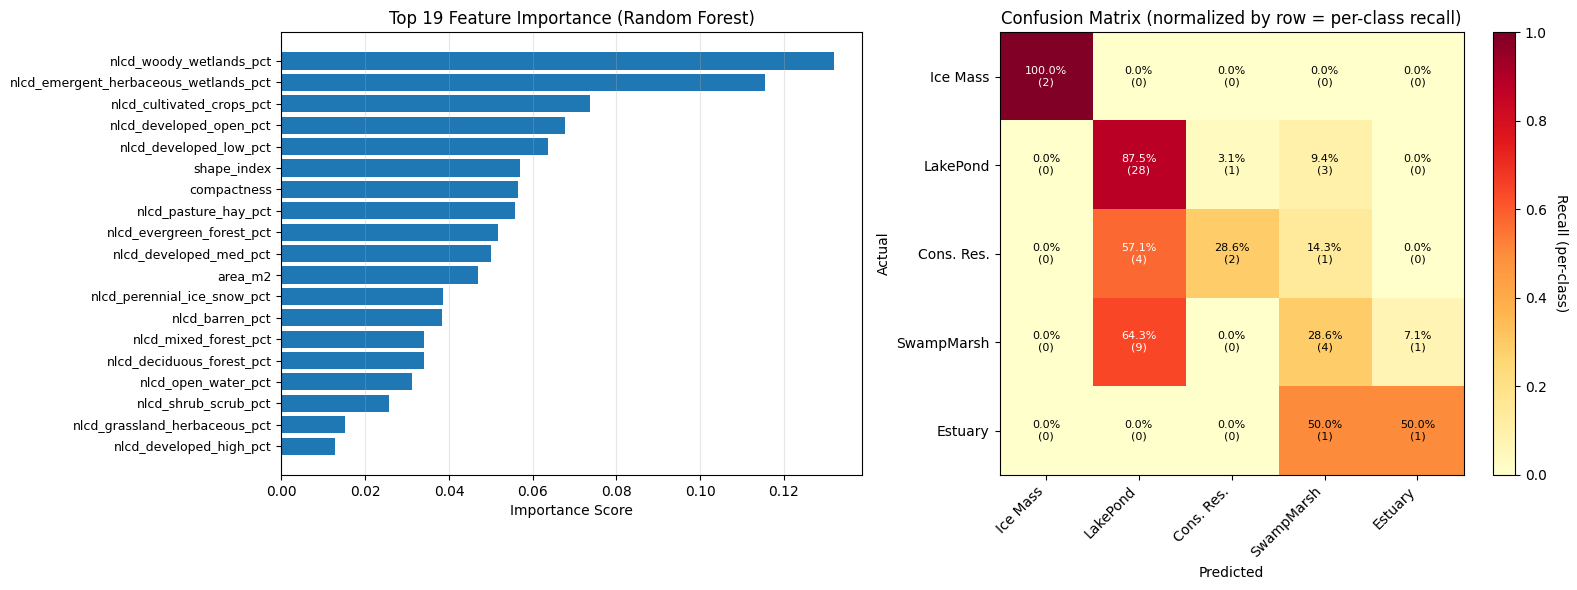


Visualization displayed above.


In [8]:
# Feature importance
print("\n" + "="*70)
print("FEATURE IMPORTANCE")
print("="*70)

# Get feature importances
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 Most Important Features:")
print(feature_importance.head(20).to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Full feature importance bar chart
ax1 = axes[0]
top_n = min(20, len(feature_importance))
top_features = feature_importance.head(top_n)
ax1.barh(range(len(top_features)), top_features["importance"])
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(top_features["feature"], fontsize=9)
ax1.set_xlabel("Importance Score")
ax1.set_title(f"Top {top_n} Feature Importance (Random Forest)")
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# Confusion matrix heatmap
ax2 = axes[1]

# Normalize confusion matrix by row to show per-class recall (handles class imbalance better)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Map numeric ftype codes to friendly names
ftype_names = {
    493.0: "Estuary",
    390.0: "LakePond",
    466.0: "SwampMarsh",
    436.0: "Cons. Res.",
    378.0: "Ice Mass",
    361.0: "Playa"
}
class_labels = [ftype_names.get(c, str(c)) for c in le.classes_]

im = ax2.imshow(cm_normalized, cmap="YlOrRd", aspect="auto", vmin=0, vmax=1)
ax2.set_xticks(range(len(le.classes_)))
ax2.set_yticks(range(len(le.classes_)))
ax2.set_xticklabels(class_labels, rotation=45, ha="right")
ax2.set_yticklabels(class_labels)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")
ax2.set_title("Confusion Matrix (normalized by row = per-class recall)")

# Add text annotations: show both normalized % and raw counts
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        norm_val = cm_normalized[i, j]
        raw_count = cm[i, j]
        text_label = f"{norm_val:.1%}\n({raw_count})"
        ax2.text(j, i, text_label, ha="center", va="center",
                color="white" if norm_val > 0.5 else "black", fontsize=8)

cbar = plt.colorbar(im, ax=ax2)
cbar.set_label("Recall (per-class)", rotation=270, labelpad=15)
plt.tight_layout()
plt.show()

print("\nVisualization displayed above.")


In [ ]:
# Save model predictions and model itself
import pickle

print("\n" + "="*70)
print("SAVING PREDICTIONS AND MODEL")
print("="*70)

# Add predictions back to full dataset
ml_data_with_preds = ml_data.copy()
ml_data_with_preds["ftype_predicted"] = le.inverse_transform(rf_model.predict(X))
ml_data_with_preds["ftype_confidence"] = rf_model.predict_proba(X).max(axis=1)

# Save with predictions
predictions_gpkg = os.path.join(os.getcwd(), "waterbody_predictions.gpkg")
ml_data_with_preds[["patch_id", "area_m2", "compactness", "shape_index",
                     "nhd_ftype", "ftype_predicted", "ftype_confidence",
                     "geometry"]].to_file(predictions_gpkg, driver="GPKG")
print(f"✓ Saved predictions → {predictions_gpkg}")

# Save model
model_path = os.path.join(os.getcwd(), "rf_ftype_classifier.pkl")
with open(model_path, "wb") as f:
    pickle.dump({
        "model": rf_model,
        "label_encoder": le,
        "feature_columns": feature_cols,
        "accuracy": accuracy,
        "cv_scores": cv_scores,
    }, f)
print(f"✓ Saved model → {model_path}")

print(f"\nModel Summary:")
print(f"  Accuracy (test): {accuracy:.4f}")
print(f"  CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Classes: {list(le.classes_)}")
print(f"  Features: {len(feature_cols)}")


In [ ]:
# Optional: Predict on new data using the trained model

def predict_waterbody_type(patch_features_df, model_path):
    """
    Predict waterbody ftype on new patches.
    
    Parameters:
    -----------
    patch_features_df : pd.DataFrame
        DataFrame with columns matching the trained features:
        [area_m2, compactness, shape_index, nlcd_*, ...]
    model_path : str
        Path to saved model pickle file
    
    Returns:
    --------
    predictions : np.ndarray
        Predicted ftype for each patch
    confidences : np.ndarray
        Confidence score (max probability) for each prediction
    """
    with open(model_path, "rb") as f:
        saved = pickle.load(f)
    
    model = saved["model"]
    le = saved["label_encoder"]
    feature_cols = saved["feature_columns"]
    
    # Extract features in correct order
    X_new = patch_features_df[feature_cols].fillna(0)
    
    # Predict
    y_pred_encoded = model.predict(X_new)
    y_pred = le.inverse_transform(y_pred_encoded)
    confidences = model.predict_proba(X_new).max(axis=1)
    
    return y_pred, confidences

# Example usage (uncomment to test):
# new_predictions, new_confidences = predict_waterbody_type(X, model_path)
# print(f"Predictions on new data:\n{new_predictions[:10]}")
# print(f"Confidences:\n{new_confidences[:10]}")
